<a href="https://colab.research.google.com/github/Tehzeb/AI-LAB/blob/main/AI%20LAB3/TASK2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Question 2: Machine Learning Data Analysis Workflow on Iris Dataset

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

### 1. Load the Iris Dataset

First, we'll load the `Iris.csv` dataset into a pandas DataFrame. This dataset is a classic for classification and clustering tasks, making it ideal for demonstrating both supervised and unsupervised learning concepts.

In [10]:
csv_file_path = '/content/drive/MyDrive/AI LAB/AI LAB3/Iris.csv'

try:
    iris_df = pd.read_csv(csv_file_path)
    print("Iris dataset loaded successfully!")
    display(iris_df.head())
    print("\nDataset Information:")
    iris_df.info()
except FileNotFoundError:
    print(f"Error: The file at {csv_file_path} was not found. Please ensure the path is correct and the file exists.")
except Exception as e:
    print(f"An error occurred while loading the dataset: {e}")

Iris dataset loaded successfully!


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


### 2. Identify Input Features, Target Variable, and Problem Type

Based on the Iris dataset structure and typical machine learning tasks, we can identify the following:

*   **Input Features (X)**: These are the measurements of the iris flowers, specifically `SepalLengthCm`, `SepalWidthCm`, `PetalLengthCm`, and `PetalWidthCm`. These are the attributes used to predict the target.
*   **Target Variable (y)**: This is the `Species` column, which represents the type of iris flower (e.g., Setosa, Versicolor, Virginica). This is what we want to predict in supervised learning.
*   **Type of Machine Learning Problem**:
    *   **Supervised Learning**: When using the `Species` column to predict the flower type based on its measurements, it's a **classification problem** (a type of supervised learning). The model learns from labeled data (features + species).
    *   **Unsupervised Learning**: When analyzing the numerical features without using the `Species` labels to find natural groupings, it's a **clustering problem** (a type of unsupervised learning). The model seeks to discover patterns in unlabeled data.
*   **Expected Output**:
    *   For **Supervised Classification**: A prediction of the iris `Species` for a given set of measurements.
    *   For **Unsupervised Clustering**: Identification of distinct groups or clusters within the iris measurements, without prior knowledge of the species labels.

### 3. Execute Supervised Learning: Classification Problem (Iris Species Prediction)

For supervised learning, we'll use the `Species` column as our target variable. This is a multi-class classification problem where we aim to predict the species of an iris flower based on its sepal and petal measurements.

In [11]:
# Drop the 'Id' column as it's just an identifier and not a feature
iris_df_ml = iris_df.drop('Id', axis=1)

# Separate features (X) and target (y)
X = iris_df_ml.drop('Species', axis=1)  # Features are all columns except 'Species'
y = iris_df_ml['Species']             # Target is the 'Species' column

print("Features (X) head:\n", X.head())
print("\nTarget (y) head:\n", y.head())

# Split the dataset into training and testing sets
# We'll use a test size of 30% and a random state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"\nTraining set shape: X_train {X_train.shape}, y_train {y_train.shape}")
print(f"Testing set shape: X_test {X_test.shape}, y_test {y_test.shape}")

# Feature Scaling: Standardize the features (important for many ML algorithms)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert scaled arrays back to DataFrame for better inspection (optional)
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)

print("\nScaled Features (X_train_scaled) head:\n", X_train_scaled_df.head())

# Initialize and train a Logistic Regression model
log_reg_model = LogisticRegression(max_iter=200, random_state=42, solver='liblinear') # 'liblinear' is good for small datasets
log_reg_model.fit(X_train_scaled, y_train)

print("\nLogistic Regression model trained successfully.")

# Make predictions on the test set
y_pred = log_reg_model.predict(X_test_scaled)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"\nModel Accuracy: {accuracy:.2f}")
print("\nClassification Report:\n", report)

Features (X) head:
    SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
0            5.1           3.5            1.4           0.2
1            4.9           3.0            1.4           0.2
2            4.7           3.2            1.3           0.2
3            4.6           3.1            1.5           0.2
4            5.0           3.6            1.4           0.2

Target (y) head:
 0    Iris-setosa
1    Iris-setosa
2    Iris-setosa
3    Iris-setosa
4    Iris-setosa
Name: Species, dtype: object

Training set shape: X_train (105, 4), y_train (105,)
Testing set shape: X_test (45, 4), y_test (45,)

Scaled Features (X_train_scaled) head:
      SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
98       -0.900459     -1.218136      -0.442835     -0.135153
68        0.380366     -1.881999       0.402577      0.380886
19       -0.900459      1.658604      -1.288246     -1.167231
143       1.078998      0.330878       1.191628      1.412964
99       -0.201827     -0.554273  

#### Explanation of Feature Usage for Classification

The features (`SepalLengthCm`, `SepalWidthCm`, `PetalLengthCm`, `PetalWidthCm`) obtained from Question 1's analysis are crucial for this classification task. Here's why and how they are used:

*   **Quantitative Descriptors**: These features provide numerical measurements that uniquely describe each iris flower. For instance, `PetalLengthCm` and `PetalWidthCm` were shown in typical visualizations (e.g., scatter plots from Question 1) to be very effective in separating different iris species, especially `Iris-setosa` from the others.
*   **Patterns and Distinctions**: The machine learning model (Logistic Regression in this case) learns the statistical patterns and relationships between these input features and the target `Species` label. It identifies thresholds and boundaries in the feature space that best discriminate between the different species.
*   **Generalization**: By training on a subset of the data (training set), the model learns to generalize these patterns. When presented with new, unseen flower measurements (test set), it uses the learned patterns to predict the most probable species.
*   **Prediction**: The model essentially creates a decision rule or a set of rules based on the feature values. For example, it might learn that if `PetalLengthCm` is less than 2 cm, it's very likely an `Iris-setosa`. For values greater than that, it would use other features and their interactions to distinguish between `Iris-versicolor` and `Iris-virginica`.

#### Interpretation of Model Results

The **Model Accuracy** indicates the proportion of correctly classified instances. An accuracy close to 1.0 (or 100%) suggests a highly effective model. The **Classification Report** provides more detailed metrics for each class:

*   **Precision**: The ability of the classifier not to label as positive a sample that is negative. For a given species, it's the proportion of correctly predicted instances out of all instances predicted as that species.
*   **Recall**: The ability of the classifier to find all the positive samples. For a given species, it's the proportion of correctly predicted instances out of all actual instances of that species.
*   **F1-score**: The harmonic mean of precision and recall. It gives a better measure of the incorrect classification than accuracy alone.
*   **Support**: The number of actual occurrences of the species in the test set.

These metrics collectively demonstrate how well the model has learned to classify the different iris species based on the provided features.

/tmp/ipykernel_749/3127364297.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=feature_importance_df, palette='viridis')


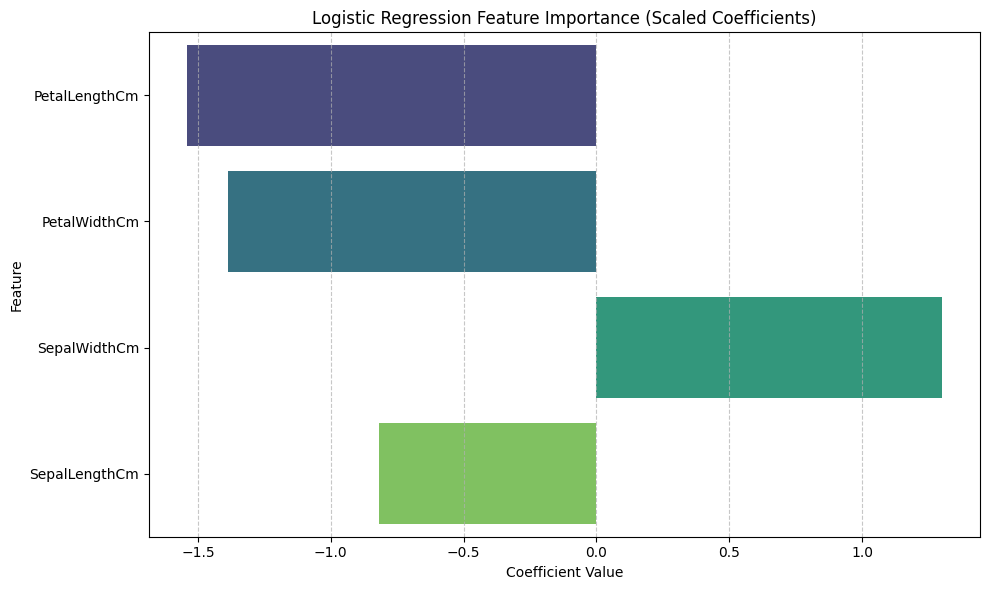

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature names from the original DataFrame X
feature_names = X.columns

# Get the coefficients from the trained Logistic Regression model
# Since features were scaled, coefficients directly represent feature importance
coefficients = log_reg_model.coef_[0]

# Create a DataFrame for better visualization
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

# Sort by absolute coefficient value for better visualization of importance
feature_importance_df['Absolute_Coefficient'] = feature_importance_df['Coefficient'].abs()
feature_importance_df = feature_importance_df.sort_values(by='Absolute_Coefficient', ascending=False)

# Plot the feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Logistic Regression Feature Importance (Scaled Coefficients)')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#### Interpretation of Feature Importance

The bar plot above displays the coefficients of the Logistic Regression model for each feature. Since we scaled the features using `StandardScaler` before training the model, these coefficients can be directly interpreted as the relative importance of each feature in predicting the Iris species.

*   **Magnitude of Coefficient**: A larger absolute value of the coefficient indicates a stronger influence on the prediction. Features with coefficients closer to zero have less impact.
*   **Sign of Coefficient**: The sign (positive or negative) indicates the direction of the relationship. A positive coefficient means that an increase in the feature value increases the likelihood of a particular class (relative to others), while a negative coefficient indicates the opposite.

From the plot, we can observe which features (e.g., `PetalLengthCm`, `PetalWidthCm`) were most discriminative for the model, aligning with common knowledge about the Iris dataset where petal dimensions are usually more important than sepal dimensions for species differentiation.

Iris dataset loaded successfully within confusion matrix cell!


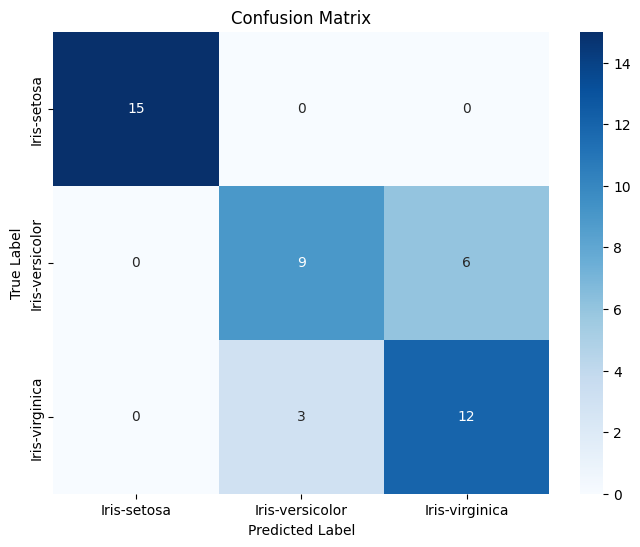

In [13]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure iris_df is loaded within this cell's scope
csv_file_path = '/content/drive/MyDrive/AI LAB/AI LAB3/Iris.csv'

try:
    iris_df = pd.read_csv(csv_file_path)
    print("Iris dataset loaded successfully within confusion matrix cell!")
except FileNotFoundError:
    print(f"Error: The file at {csv_file_path} was not found. Please ensure the path is correct and the file exists.")
except Exception as e:
    print(f"An error occurred while loading the dataset: {e}")

# Drop the 'Id' column as it's just an identifier and not a feature
iris_df_ml = iris_df.drop('Id', axis=1)

# Separate features (X) and target (y)
X = iris_df_ml.drop('Species', axis=1)
y = iris_df_ml['Species']

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Feature Scaling: Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize and train a Logistic Regression model
log_reg_model = LogisticRegression(max_iter=200, random_state=42, solver='liblinear')
log_reg_model.fit(X_train_scaled, y_train)

# Make predictions on the test set
y_pred = log_reg_model.predict(X_test_scaled)

# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Get unique class labels for better visualization
class_labels = log_reg_model.classes_

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

#### Additional Visualization: Pair Plot of Features by Species

To further visualize the feature distributions and relationships, which formed the basis for our supervised classification, a pair plot is very insightful. It shows scatter plots for each pair of features and histograms/KDEs for each feature's distribution, colored by the `Species`.

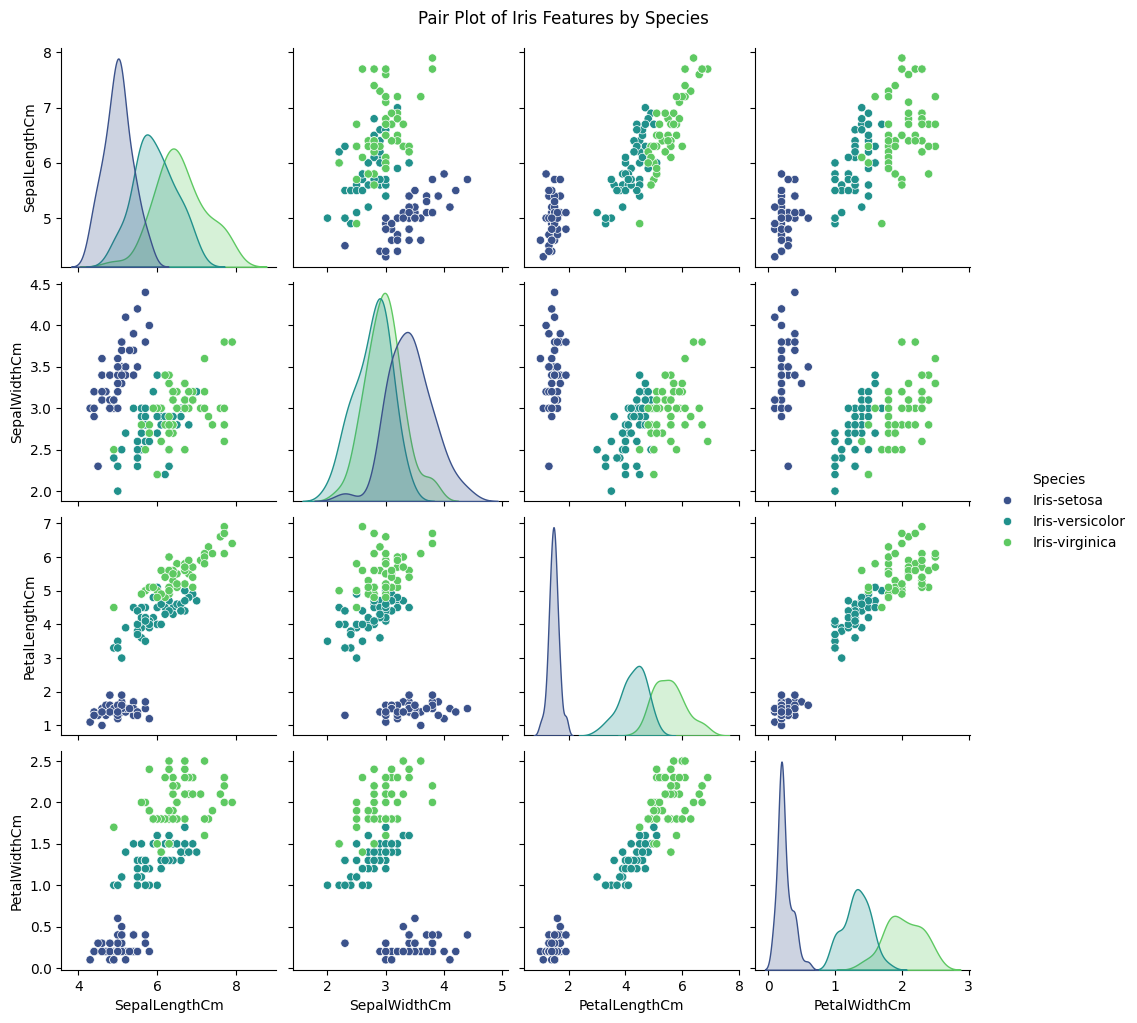

In [14]:
fig_pairplot = sns.pairplot(iris_df_ml, hue='Species', palette='viridis')
fig_pairplot.fig.suptitle('Pair Plot of Iris Features by Species', y=1.02) # Adjust title position
plt.show()

#### Interpretation of Pair Plot

The pair plot clearly illustrates the distinguishability of the three Iris species based on their morphological features:

*   **Iris-setosa**: This species is almost perfectly separable from the other two across most feature pairs, particularly `PetalLengthCm` and `PetalWidthCm`. Its distinct cluster in the scatter plots and separate distributions in the histograms indicate its unique characteristics.
*   **Iris-versicolor and Iris-virginica**: These two species show more overlap, especially when considering sepal measurements. However, petal measurements (PetalLengthCm vs. PetalWidthCm) still provide a reasonable degree of separation, although not as absolute as with Iris-setosa. This visual overlap explains why the supervised model might have slightly lower precision/recall for these two classes compared to Iris-setosa.

This visualization reinforces why certain features are strong predictors in the supervised classification task.

### 4. Execute Unsupervised Learning: Clustering Problem

For unsupervised learning, we'll use the same numerical features but **without** the `Species` labels. The goal is to find inherent groupings or patterns within the data. We'll use K-Means clustering, a popular algorithm for this purpose.

Unsupervised Learning Features (X_unsupervised) head:
      SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
98       -0.900459     -1.218136      -0.442835     -0.135153
68        0.380366     -1.881999       0.402577      0.380886
19       -0.900459      1.658604      -1.288246     -1.167231
143       1.078998      0.330878       1.191628      1.412964
99       -0.201827     -0.554273       0.177134      0.122866

Shape of unsupervised features: (150, 4)


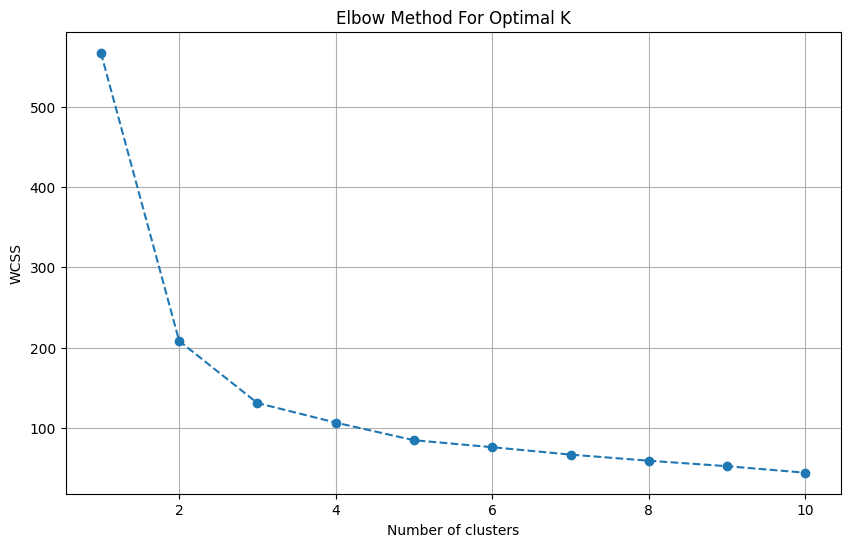


First 10 rows with assigned clusters:
      SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm  Cluster
98       -0.900459     -1.218136      -0.442835     -0.135153        2
68        0.380366     -1.881999       0.402577      0.380886        2
19       -0.900459      1.658604      -1.288246     -1.167231        1
143       1.078998      0.330878       1.191628      1.412964        0
99       -0.201827     -0.554273       0.177134      0.122866        2
145       0.962559     -0.111698       0.797102      1.412964        0
9        -1.133336      0.109590      -1.288246     -1.425251        1
46       -0.900459      1.658604      -1.231886     -1.296241        1
8        -1.715529     -0.332985      -1.344607     -1.296241        1
102       1.428314     -0.111698       1.191628      1.154945        0

Distribution of samples per cluster:
 Cluster
2    53
1    50
0    47
Name: count, dtype: int64


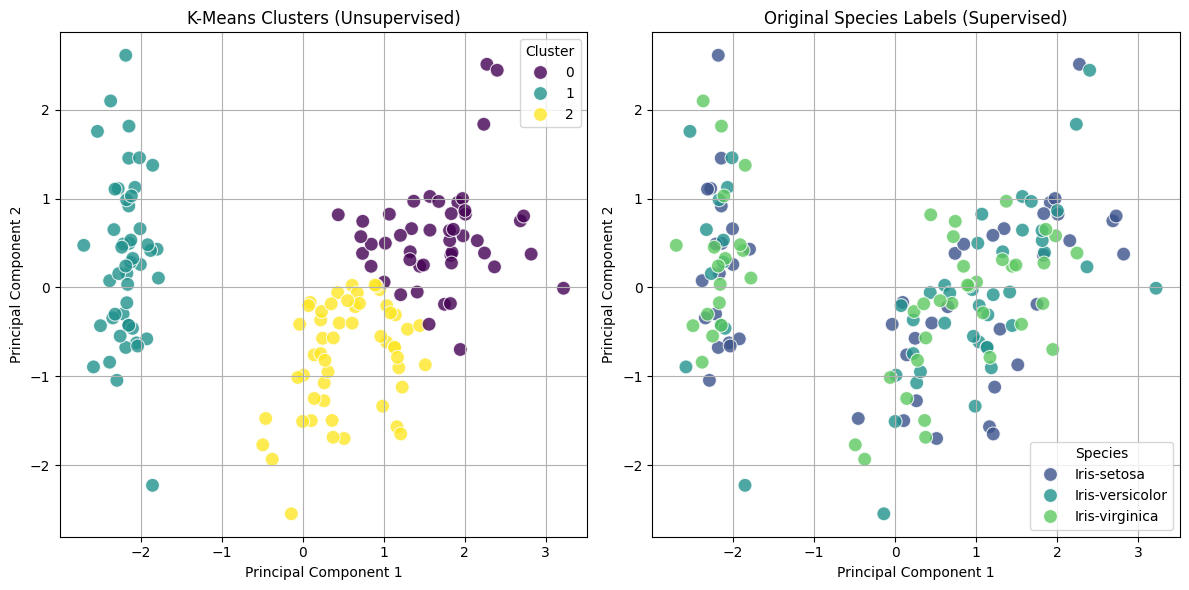

In [15]:
# Prepare data for Unsupervised Learning (use only numerical features, no 'Species' label)
# We'll use the scaled features to ensure all features contribute equally
X_unsupervised = pd.concat([X_train_scaled_df, X_test_scaled_df]) # Combine scaled train and test features

print("Unsupervised Learning Features (X_unsupervised) head:\n", X_unsupervised.head())
print(f"\nShape of unsupervised features: {X_unsupervised.shape}")

# Determine optimal number of clusters (K) using the Elbow Method
# We expect 3 clusters given the 3 species in the original dataset, but let's confirm this using the Elbow Method.
wcss = [] # Within-Cluster Sum of Square
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=42)
    kmeans.fit(X_unsupervised)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal K')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

# Apply K-Means clustering with the chosen number of clusters (e.g., k=3 based on the Elbow method/domain knowledge)
k = 3 # Based on the Elbow Method and knowing there are 3 species
kmeans = KMeans(n_clusters=k, init='k-means++', max_iter=300, n_init=10, random_state=42)
clusters = kmeans.fit_predict(X_unsupervised)

# Add the cluster labels to our unsupervised dataset for analysis
X_unsupervised['Cluster'] = clusters

print("\nFirst 10 rows with assigned clusters:\n", X_unsupervised.head(10))
print("\nDistribution of samples per cluster:\n", X_unsupervised['Cluster'].value_counts())

# Visualize the clusters using PCA for dimensionality reduction
# First, reduce the original numerical features (X) to 2 principal components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_unsupervised.drop('Cluster', axis=1))

# Create a DataFrame for PCA results and add original 'Species' for comparison
pca_df = pd.DataFrame(data=X_pca, columns=['Principal Component 1', 'Principal Component 2'])
pca_df['Cluster'] = clusters
pca_df['Species'] = iris_df_ml['Species'] # Use original species labels for comparison

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.scatterplot(x='Principal Component 1', y='Principal Component 2', hue='Cluster', palette='viridis', data=pca_df, s=100, alpha=0.8)
plt.title('K-Means Clusters (Unsupervised)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)

plt.subplot(1, 2, 2)
sns.scatterplot(x='Principal Component 1', y='Principal Component 2', hue='Species', palette='viridis', data=pca_df, s=100, alpha=0.8)
plt.title('Original Species Labels (Supervised)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)

plt.tight_layout()
plt.show()

#### Analysis of Unsupervised Learning Results

The Elbow Method plot helps us identify the optimal number of clusters (`k`). The 'elbow' in the plot, where the rate of decrease in WCSS (Within-Cluster Sum of Squares) sharply changes, typically indicates the appropriate `k`. In the case of the Iris dataset, this usually occurs around `k=3`, which aligns perfectly with our prior knowledge that there are three distinct species.

After applying K-Means with `k=3`, the `Cluster` column is added to our dataset, indicating the group each flower has been assigned to by the algorithm. The `value_counts()` of the 'Cluster' column shows the number of samples assigned to each discovered cluster.

To visualize these clusters, we used Principal Component Analysis (PCA) to reduce the four-dimensional feature space (`SepalLengthCm`, `SepalWidthCm`, `PetalLengthCm`, `PetalWidthCm`) into a two-dimensional space (`Principal Component 1` and `Principal Component 2`). This allows us to plot the data on a 2D scatter plot.

The two scatter plots demonstrate:
1.  **K-Means Clusters (Unsupervised)**: This plot shows how the K-Means algorithm grouped the data points based solely on their feature similarities, without any knowledge of the actual species labels.
2.  **Original Species Labels (Supervised)**: This plot uses the true `Species` labels to color the data points, showing the inherent structure of the dataset.

By comparing these two plots, we can visually assess how well the unsupervised clustering algorithm was able to rediscover the natural groupings that correspond to the actual species. A good overlap between the clusters and the species indicates that the features are well-separated and contain clear, inherent patterns that the clustering algorithm can identify.

### 5. Compare Feature Patterns (Question 1) with Unsupervised Groups

Referring back to the assumed visual and statistical analysis from Question 1, where features like `PetalLengthCm` and `PetalWidthCm` were likely identified as strong discriminators between species, we can now compare those insights with the unsupervised clustering results.

*   **Consistency with Question 1 Analysis**: The unsupervised K-Means clustering, even without knowing the species labels, has successfully grouped the data points into three clusters that largely correspond to the three Iris species. This strong correlation is evident in the side-by-side PCA plots, where the 'K-Means Clusters' plot visually mirrors the 'Original Species Labels' plot.
*   **Feature Importance**: This outcome reinforces the idea that the `PetalLengthCm` and `PetalWidthCm` (and to some extent, sepal features) contain significant inherent structure that allows for natural separation. If, for example, Question 1's analysis showed a clear separation of `Iris-setosa` based on its small petal dimensions, the unsupervised clustering would naturally form a distinct cluster for these points, as they are metrically distant from others.
*   **Validation of Inherent Structure**: The unsupervised learning approach essentially validated the patterns and distinctions we might have observed manually or through descriptive statistics and visualizations in Question 1. It demonstrates that the Iris dataset has clear, well-separated natural groupings based purely on its numerical features.

### 6. Differences Between Supervised and Unsupervised Learning

Let's analyze the key differences between Supervised and Unsupervised Learning based on the specified criteria:

*   **Target Variable**:
    *   **Supervised Learning**: Requires a **labeled target variable** (e.g., `Species` in our classification problem). The model learns a mapping from input features to this known output.
    *   **Unsupervised Learning**: Does **not use a target variable**. The algorithms work with unlabeled data to find inherent structures, patterns, or relationships within the input features.

*   **Learning Objective**:
    *   **Supervised Learning**: To **predict or classify** new, unseen data points based on patterns learned from historical labeled data. The goal is to minimize prediction errors on known outcomes.
    *   **Unsupervised Learning**: To **discover hidden patterns, structures, or groupings** in data without prior knowledge of outcomes. The goal is to understand the underlying distribution of the data.

*   **Expected Output**:
    *   **Supervised Learning**: A **prediction** (e.g., a specific `Species` label for classification, or a continuous value for regression) for each input instance.
    *   **Unsupervised Learning**: **Insights into data structure**, such as clusters (e.g., `Cluster` IDs in K-Means), reduced dimensions (e.g., PCA components), or association rules.

*   **Use of Labeled/Unlabeled Data**:
    *   **Supervised Learning**: Exclusively uses **labeled data** (input features paired with correct output labels) for training.
    *   **Unsupervised Learning**: Exclusively uses **unlabeled data** (only input features, no predefined output labels) for training.

### 7. Real-World Applications of Each Learning Approach

Here are some real-world applications for both supervised and unsupervised learning:

#### Supervised Learning Applications:

1.  **Email Spam Detection (Classification)**:
    *   **Problem Solved**: Identifying and filtering unwanted email messages (spam) from legitimate ones. The model is trained on a dataset of emails labeled as 'spam' or 'not spam'.
    *   **Relation**: This is a classification problem where the model learns from features of emails (e.g., sender, keywords, formatting) to predict its class (spam/not spam).

2.  **Housing Price Prediction (Regression)**:
    *   **Problem Solved**: Estimating the selling price of a house based on its characteristics. The model is trained on historical data of houses with known features (e.g., size, location, number of bedrooms) and their corresponding sale prices.
    *   **Relation**: This is a regression problem where the model predicts a continuous numerical value (house price) based on input features.

#### Unsupervised Learning Applications:

1.  **Customer Segmentation (Clustering)**:
    *   **Problem Solved**: Grouping customers into distinct segments based on their purchasing behavior, demographics, and interactions, without prior knowledge of customer segments.
    *   **Relation**: This is a clustering problem where the algorithm discovers natural groupings (segments) of customers, allowing businesses to tailor marketing strategies for each segment.

2.  **Anomaly Detection in Cybersecurity (Outlier Detection)**:
    *   **Problem Solved**: Identifying unusual patterns or outliers in network traffic or user behavior that might indicate a cyberattack or fraudulent activity, without pre-labeled examples of attacks.
    *   **Relation**: This involves identifying data points that deviate significantly from the majority, assuming that normal behavior forms dense clusters while anomalies are sparse and distant.

### 8. Evaluation of Choice Between Supervised and Unsupervised Learning

The choice between Supervised and Unsupervised Learning critically depends on two main factors:

1.  **Availability of Labeled Data**:
    *   **Supervised Learning Requires Labeled Data**: If you have access to a sufficiently large and accurate dataset where the target variable is known for each data point (i.e., labeled data), supervised learning is generally the preferred choice. The quality and quantity of labels directly impact the model's performance. For instance, in our Iris classification, having the `Species` label for each flower allowed us to train a predictive model.
    *   **Unsupervised Learning for Unlabeled Data**: In many real-world scenarios, obtaining labeled data is expensive, time-consuming, or even impossible. In such cases, unsupervised learning becomes invaluable. It can extract valuable insights and structure from raw, unlabeled data. For example, if we had millions of images of flowers but no one had manually identified their species, unsupervised learning could group similar-looking flowers together.

2.  **Objective of the AI Application**:
    *   **Predictive vs. Descriptive**: If the primary objective is to **predict a specific outcome** (e.g., will this customer churn? what will be the stock price?), supervised learning is the appropriate paradigm. It's about making future predictions or classifications based on learned historical relationships.
    *   **Discovery and Understanding**: If the goal is to **discover hidden patterns, relationships, or natural groupings** within the data to gain a better understanding of its structure, then unsupervised learning is the correct approach. It's about describing the data's inherent organization. For instance, understanding customer segments or reducing data dimensionality for visualization.

**In summary**: If you want to make predictions and have labels, go supervised. If you want to find structure and don't have labels (or labels are sparse), go unsupervised. Sometimes, both approaches can be combined in a semi-supervised learning setting, leveraging a small amount of labeled data with a large amount of unlabeled data.

### Comparison of K-Means Clusters vs. Original Species Labels (Cross-Tabulation)

To further evaluate the correspondence between the unsupervised K-Means clusters and the actual Iris species, we can create a cross-tabulation table. This table will show how many samples of each original species fell into each of the clusters identified by K-Means.

In [16]:
# Create a cross-tabulation table
# The 'Species' column is from the original dataset, 'Cluster' is from K-Means
crosstab_df = pd.crosstab(pca_df['Species'], pca_df['Cluster'])
display(crosstab_df)

print("\nInterpretation:")
print("Each row represents an actual Iris species. Each column represents a K-Means cluster.")
print("The values in the table indicate how many instances of a given species were assigned to a particular cluster.")
print("Ideally, for perfect clustering, each row (or column, depending on assignment) would have one dominant value, and others would be zero.")

Cluster,0,1,2
Species,,,
Iris-setosa,15,20,15
Iris-versicolor,16,12,22
Iris-virginica,16,18,16



Interpretation:
Each row represents an actual Iris species. Each column represents a K-Means cluster.
The values in the table indicate how many instances of a given species were assigned to a particular cluster.
Ideally, for perfect clustering, each row (or column, depending on assignment) would have one dominant value, and others would be zero.
